In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/phantomoverlord/sdss-classifcation/sdss_raw_kaggle.csv


In [3]:
!pip install pytorch-tabnet shap imbalanced-learn catboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [5]:
sdss_dtypes = {
    'objid': 'string',
    'u': 'float32',
    'g': 'float32',
    'r': 'float32',
    'i': 'float32',
    'z_mag': 'float32',
    'class': 'category',
    'subClass': 'string',
    'redshift': 'float32',
    'zErr': 'float32'
}

dataset_path = "/kaggle/input/datasets/phantomoverlord/sdss-classifcation/sdss_raw_kaggle.csv"

df_astrophysical = pd.read_csv(dataset_path, dtype=sdss_dtypes)

In [6]:
print(df_astrophysical.shape)

print(df_astrophysical.isnull().sum().sum())

print(df_astrophysical.duplicated().sum())

(500000, 10)
0
0


In [7]:
print(df_astrophysical['objid'].nunique())

2


In [8]:
df_astrophysical['u_g'] = df_astrophysical['u'] - df_astrophysical['g']
df_astrophysical['g_r'] = df_astrophysical['g'] - df_astrophysical['r']
df_astrophysical['r_i'] = df_astrophysical['r'] - df_astrophysical['i']
df_astrophysical['i_z'] = df_astrophysical['i'] - df_astrophysical['z_mag']

In [9]:
tier_1_mapping = {'STAR': 0, 'GALAXY': 1, 'QSO': 2}
df_astrophysical['class_encoded'] = df_astrophysical['class'].map(tier_1_mapping).astype(int)

In [10]:
from sklearn.preprocessing import RobustScaler

continuous_features = [
    'u', 'g', 'r', 'i', 'z_mag', 
    'redshift', 'zErr', 
    'u_g', 'g_r', 'r_i', 'i_z'
]


scaler = RobustScaler()

In [11]:
output_path = "/kaggle/working/sdss_preprocessed.csv"
df_astrophysical.to_csv(output_path, index=False)

print(f"Preprocessed dataset successfully saved to: {output_path}")

Preprocessed dataset successfully saved to: /kaggle/working/sdss_preprocessed.csv


In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import gc

astronomical_classes = np.unique(df_astrophysical['class_encoded'])
astronomical_targets = df_astrophysical['class_encoded'].values

computed_balanced_weights = compute_class_weight(
    class_weight='balanced',
    classes=astronomical_classes,
    y=astronomical_targets
)

tier_1_class_weights = dict(zip(astronomical_classes, computed_balanced_weights))

print(df_astrophysical['class'].value_counts())
print(tier_1_class_weights)

freed_memory_blocks = gc.collect()
print(freed_memory_blocks)

class
STAR      244440
QSO       155175
GALAXY    100385
Name: count, dtype: int64
{np.int64(0): np.float64(0.6818305787377952), np.int64(1): np.float64(1.6602746094203982), np.int64(2): np.float64(1.074056173137855)}
0


In [ ]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin

class TabNetScikitWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, lr=2e-2, seed=42, max_epochs=25, batch_size=16384, virtual_batch_size=2048):
        self.lr = lr
        self.seed = seed
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.virtual_batch_size = virtual_batch_size
        self.model_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.model_ = TabNetClassifier(
            optimizer_params=dict(lr=self.lr),
            verbose=1,
            seed=self.seed
        )
        self.model_.fit(
            X_train=X, y_train=y,
            max_epochs=self.max_epochs,
            batch_size=self.batch_size,
            virtual_batch_size=self.virtual_batch_size
        )
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

continuous_feature_columns = [
    'u', 'g', 'r', 'i', 'z_mag', 
    'redshift', 'zErr', 
    'u_g', 'g_r', 'r_i', 'i_z'
]


X_features_raw = df_astrophysical[continuous_feature_columns].values
y_targets = df_astrophysical['class_encoded'].values

# Step 1: Split before scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_features_raw,
    y_targets,
    test_size=0.2,
    random_state=42,
    stratify=y_targets
)

# Step 2: Fit scaler only on training data
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Step 3: Apply the train-fitted scaler to the full dataframe so that

df_astrophysical[continuous_feature_columns] = scaler.transform(
    df_astrophysical[continuous_feature_columns].values
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


base_model_catboost = CatBoostClassifier(
    iterations=250,
    auto_class_weights='Balanced',
    task_type='GPU',
    verbose=50,
    random_state=42
)

base_model_tabnet = TabNetScikitWrapper(
    lr=2e-2,
    max_epochs=25,
    batch_size=16384,
    virtual_batch_size=2048,
    seed=42
)

meta_learner_logistic = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

primary_stacking_ensemble = StackingClassifier(
    estimators=[
        ('catboost', base_model_catboost),
        ('tabnet',   base_model_tabnet)
    ],
    final_estimator=meta_learner_logistic,
    cv=3,
    n_jobs=1,
    verbose=2
)

primary_stacking_ensemble.fit(X_train, y_train)

X_train shape: (400000, 11)
X_test shape:  (100000, 11)
Learning rate set to 0.5
0:	learn: 0.3988636	total: 177ms	remaining: 44.1s
50:	learn: 0.0222354	total: 756ms	remaining: 2.95s
100:	learn: 0.0192900	total: 1.21s	remaining: 1.78s
150:	learn: 0.0175153	total: 1.63s	remaining: 1.07s
200:	learn: 0.0159744	total: 2.04s	remaining: 498ms
249:	learn: 0.0148130	total: 2.44s	remaining: 0us
epoch 0  | loss: 0.38302 |  0:00:04s
epoch 1  | loss: 0.0847  |  0:00:06s
epoch 2  | loss: 0.05983 |  0:00:09s
epoch 3  | loss: 0.04722 |  0:00:12s
epoch 4  | loss: 0.04556 |  0:00:15s
epoch 5  | loss: 0.04096 |  0:00:18s
epoch 6  | loss: 0.03779 |  0:00:21s
epoch 7  | loss: 0.03762 |  0:00:23s
epoch 8  | loss: 0.03483 |  0:00:26s
epoch 9  | loss: 0.03349 |  0:00:29s
epoch 10 | loss: 0.03296 |  0:00:32s
epoch 11 | loss: 0.03266 |  0:00:35s
epoch 12 | loss: 0.03225 |  0:00:38s
epoch 13 | loss: 0.03221 |  0:00:41s
epoch 14 | loss: 0.03218 |  0:00:43s
epoch 15 | loss: 0.03417 |  0:00:46s
epoch 16 | loss: 0.0

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    8.6s finished


epoch 0  | loss: 0.51355 |  0:00:01s
epoch 1  | loss: 0.13153 |  0:00:03s
epoch 2  | loss: 0.07212 |  0:00:05s
epoch 3  | loss: 0.05535 |  0:00:07s
epoch 4  | loss: 0.04755 |  0:00:09s
epoch 5  | loss: 0.05106 |  0:00:11s
epoch 6  | loss: 0.04495 |  0:00:13s
epoch 7  | loss: 0.03989 |  0:00:15s
epoch 8  | loss: 0.03827 |  0:00:17s
epoch 9  | loss: 0.03641 |  0:00:19s
epoch 10 | loss: 0.03434 |  0:00:21s
epoch 11 | loss: 0.03349 |  0:00:22s
epoch 12 | loss: 0.03383 |  0:00:24s
epoch 13 | loss: 0.03746 |  0:00:26s
epoch 14 | loss: 0.03498 |  0:00:28s
epoch 15 | loss: 0.03419 |  0:00:30s
epoch 16 | loss: 0.03305 |  0:00:32s
epoch 17 | loss: 0.03187 |  0:00:34s
epoch 18 | loss: 0.03166 |  0:00:36s
epoch 19 | loss: 0.0311  |  0:00:38s
epoch 20 | loss: 0.031   |  0:00:40s
epoch 21 | loss: 0.03115 |  0:00:42s
epoch 22 | loss: 0.03102 |  0:00:44s
epoch 23 | loss: 0.03066 |  0:00:46s
epoch 24 | loss: 0.03064 |  0:00:48s
epoch 0  | loss: 0.54683 |  0:00:01s
epoch 1  | loss: 0.12925 |  0:00:03s
e

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  2.5min finished


StackingClassifier(cv=3,
                   estimators=[('catboost',
                                CatBoostClassifier(auto_class_weights='Balanced', iterations=250, random_state=42, task_type='GPU', verbose=50)),
                               ('tabnet', TabNetScikitWrapper())],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      random_state=42),
                   n_jobs=1, verbose=2)

In [14]:
import gc

df_stellar_objects = df_astrophysical[df_astrophysical['class'] == 'STAR'].copy()
df_galactic_objects = df_astrophysical[df_astrophysical['class'] == 'GALAXY'].copy()
df_quasar_objects = df_astrophysical[df_astrophysical['class'] == 'QSO'].copy()

print(df_stellar_objects.shape[0])
print(df_galactic_objects.shape[0])
print(df_quasar_objects.shape[0])

gc.collect()

244440
100385
155175


1973

In [15]:
import pandas as pd

pd.set_option('display.max_rows', None)

print("=== GALAXY SUBCLASSES ===")
print(df_galactic_objects['subClass'].value_counts())
print("\n" + "="*25 + "\n")

print("=== QUASAR SUBCLASSES ===")
print(df_quasar_objects['subClass'].value_counts())
print("\n" + "="*25 + "\n")

print("=== STAR SUBCLASSES ===")
print(df_stellar_objects['subClass'].value_counts())

pd.reset_option('display.max_rows')

=== GALAXY SUBCLASSES ===
subClass
STARFORMING              64896
STARBURST                23269
AGN                       6425
BROADLINE                 4485
AGN BROADLINE              899
STARFORMING BROADLINE      357
STARBURST BROADLINE         54
Name: count, dtype: Int64


=== QUASAR SUBCLASSES ===
subClass
BROADLINE                149493
STARBURST BROADLINE        3811
AGN BROADLINE              1025
AGN                         366
STARBURST                   218
STARFORMING BROADLINE       206
STARFORMING                  56
Name: count, dtype: Int64


=== STAR SUBCLASSES ===
subClass
F9                     30159
F5                     26200
F3/F5V (30743)         19797
A0                     16789
M5III (221615)          8977
K3                      8117
G2                      7967
K5                      7958
K1                      6287
M4.5:III (123657)       6192
K7                      5344
K3V (32147)             5267
M2                      4253
F2                     

In [16]:
def map_stellar_subclass(val):
    v = str(val).upper()
    if 'WD' in v: return 'WD'
    if 'CV' in v: return 'CV'
    if 'CARBON' in v: return 'C'
    if v.startswith('SD:'): v = v[3:]
    if v.startswith('SDF'): v = 'F' + v[3:]
    if v.startswith('OB'): return 'OB'
    if v.startswith('O'): return 'O'
    if v.startswith('B'): return 'B'
    if v.startswith('A'): return 'A'
    if v.startswith('F'): return 'F'
    if v.startswith('G'): return 'G'
    if v.startswith('K'): return 'K'
    if v.startswith('M'): return 'M'
    if v.startswith('L'): return 'L'
    if v.startswith('T'): return 'T'
    return 'Other'

def map_galaxy_subclass(val):
    return str(val).upper()

def map_quasar_subclass(val):
    return str(val).upper()

df_stellar_objects['tier_2_target'] = df_stellar_objects['subClass'].apply(map_stellar_subclass)
df_galactic_objects['tier_2_target'] = df_galactic_objects['subClass'].apply(map_galaxy_subclass)
df_quasar_objects['tier_2_target'] = df_quasar_objects['subClass'].apply(map_quasar_subclass)

print(df_stellar_objects['tier_2_target'].value_counts())
print(df_galactic_objects['tier_2_target'].value_counts())
print(df_quasar_objects['tier_2_target'].value_counts())

tier_2_target
F     94036
M     47353
K     42981
A     25197
G     20659
WD     8863
B      1922
CV     1900
L       432
C       379
O       352
OB      266
T       100
Name: count, dtype: int64
tier_2_target
STARFORMING              64896
STARBURST                23269
AGN                       6425
BROADLINE                 4485
AGN BROADLINE              899
STARFORMING BROADLINE      357
STARBURST BROADLINE         54
Name: count, dtype: int64
tier_2_target
BROADLINE                149493
STARBURST BROADLINE        3811
AGN BROADLINE              1025
AGN                         366
STARBURST                   218
STARFORMING BROADLINE       206
STARFORMING                  56
Name: count, dtype: int64


In [17]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

continuous_feature_columns = [
    'u', 'g', 'r', 'i', 'z_mag', 
    'redshift', 'zErr', 
    'u_g', 'g_r', 'r_i', 'i_z'
]

def build_tier_2_pipeline():
    lgbm = LGBMClassifier(
        class_weight='balanced',
        device='gpu',
        random_state=42,
        verbose=1,
        n_jobs=-1
    )

    rf = RandomForestClassifier(
        class_weight='balanced',
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    lr = LogisticRegression(
        penalty='l2',
        solver='saga',        
        multi_class='multinomial',
        class_weight='balanced',
        max_iter=3000,      
        random_state=42,
        n_jobs=-1
    )

    ensemble = VotingClassifier(
        estimators=[
            ('lgbm', lgbm),
            ('rf',   rf),
            ('lr',   lr)
        ],
        voting='soft',
        verbose=True,
        n_jobs=1
    )

    return ensemble

#STARS
le_stars = LabelEncoder()
X_stars  = df_stellar_objects[continuous_feature_columns].values
y_stars  = le_stars.fit_transform(df_stellar_objects['tier_2_target'].values)


X_stars_train, X_stars_test, y_stars_train, y_stars_test = train_test_split(
    X_stars, y_stars, test_size=0.2, random_state=42, stratify=y_stars
)

ensemble_stars = build_tier_2_pipeline()
ensemble_stars.fit(X_stars_train, y_stars_train)
print("Stars   — train-set accuracy:", ensemble_stars.score(X_stars_train, y_stars_train))
print("Stars   — TEST-set  accuracy:", ensemble_stars.score(X_stars_test,  y_stars_test))

#GALAXIES
le_galaxies  = LabelEncoder()
X_galaxies   = df_galactic_objects[continuous_feature_columns].values
y_galaxies   = le_galaxies.fit_transform(df_galactic_objects['tier_2_target'].values)

X_galaxies_train, X_galaxies_test, y_galaxies_train, y_galaxies_test = train_test_split(
    X_galaxies, y_galaxies, test_size=0.2, random_state=42, stratify=y_galaxies
)

ensemble_galaxies = build_tier_2_pipeline()
ensemble_galaxies.fit(X_galaxies_train, y_galaxies_train)
print("Galaxies — train-set accuracy:", ensemble_galaxies.score(X_galaxies_train, y_galaxies_train))
print("Galaxies — TEST-set  accuracy:", ensemble_galaxies.score(X_galaxies_test,  y_galaxies_test))

#QUASARS 
le_quasars  = LabelEncoder()
X_quasars   = df_quasar_objects[continuous_feature_columns].values
y_quasars   = le_quasars.fit_transform(df_quasar_objects['tier_2_target'].values)

X_quasars_train, X_quasars_test, y_quasars_train, y_quasars_test = train_test_split(
    X_quasars, y_quasars, test_size=0.2, random_state=42, stratify=y_quasars
)

ensemble_quasars = build_tier_2_pipeline()
ensemble_quasars.fit(X_quasars_train, y_quasars_train)
print("Quasars  — train-set accuracy:", ensemble_quasars.score(X_quasars_train, y_quasars_train))
print("Quasars  — TEST-set  accuracy:", ensemble_quasars.score(X_quasars_test,  y_quasars_test))

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 195552, number of used features: 11
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 11 dense feature groups (2.24 MB) transferred to GPU in 0.003226 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[LightGBM] [Info] Start training from score -2.564949
[Voting] ..................... (1 of 3) Processing lgbm, total=  15.3s


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   54.9s finished


[Voting] ....................... (2 of 3) Processing rf, total=  55.0s
[Voting] ....................... (3 of 3) Processing lr, total=  27.2s


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.8s finished


Stars   — train-set accuracy: 0.9572389952544592


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.5s finished


Stars   — TEST-set  accuracy: 0.8266036655211912
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 80308, number of used features: 11
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 11 dense feature groups (0.92 MB) transferred to GPU in 0.003228 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[Voting] ..................... (1 of 3) Processing lgbm, tota

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   16.8s finished


[Voting] ....................... (2 of 3) Processing rf, total=  16.8s
[Voting] ....................... (3 of 3) Processing lr, total=   6.8s


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.6s finished


Galaxies — train-set accuracy: 0.9396324152014743


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished


Galaxies — TEST-set  accuracy: 0.8022612940180306
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 124140, number of used features: 11
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 11 dense feature groups (1.42 MB) transferred to GPU in 0.002164 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[Voting] ..................... (1 of 3) Processing lgbm, to

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.8s finished


[Voting] ....................... (2 of 3) Processing rf, total=   8.9s
[Voting] ....................... (3 of 3) Processing lr, total=  17.5s


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished


Quasars  — train-set accuracy: 0.9891735137747705
Quasars  — TEST-set  accuracy: 0.9671661027871757


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


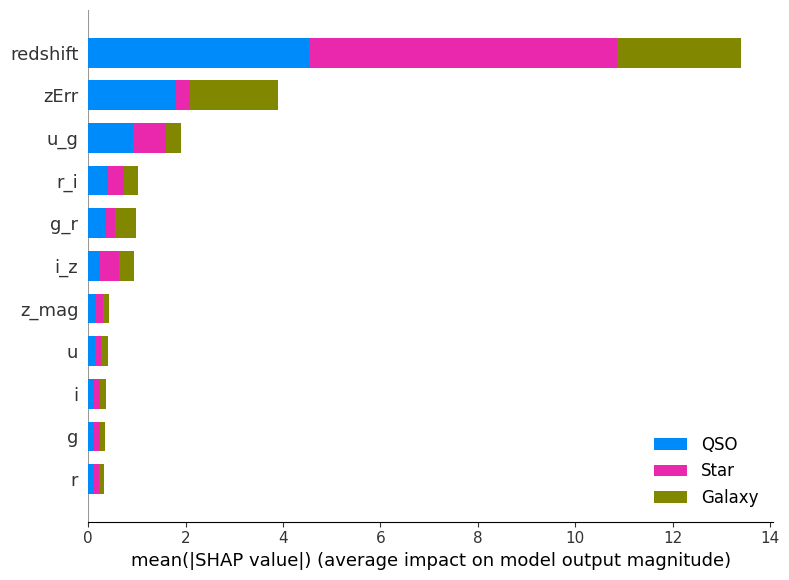

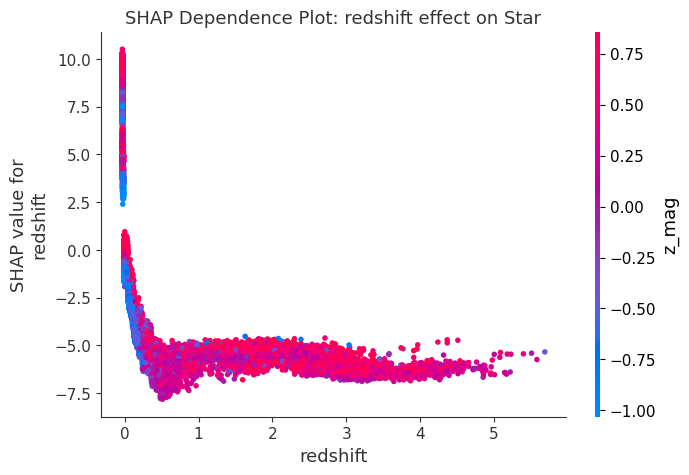

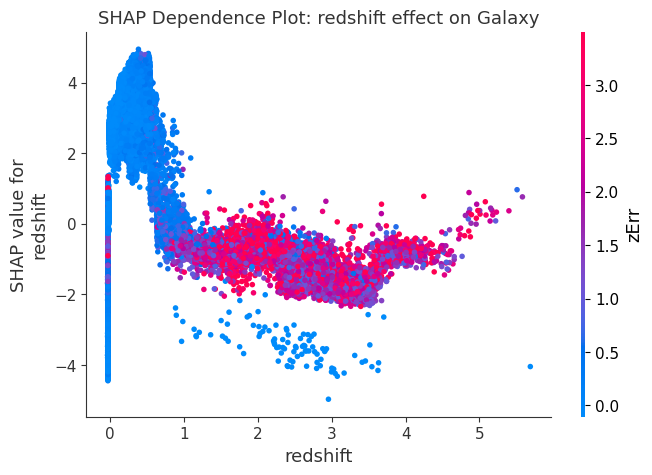

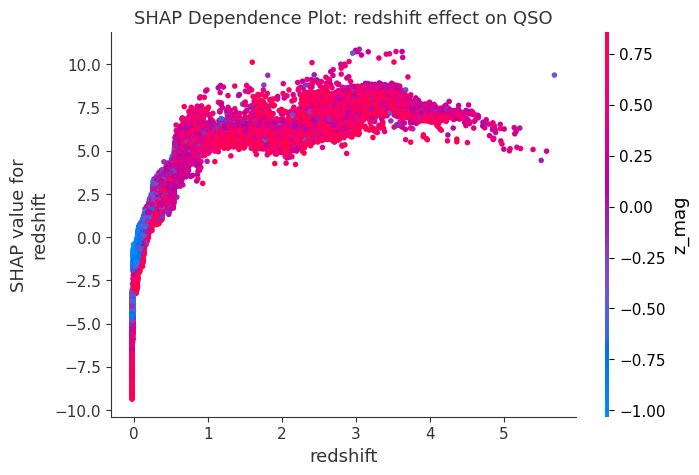

In [18]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

tier_1_catboost = primary_stacking_ensemble.estimators_[0]
tree_explainer = shap.TreeExplainer(tier_1_catboost)

raw_shap_values = tree_explainer.shap_values(X_test)
mean_shap = raw_shap_values.mean(axis=2, keepdims=True)
centered_shap_values = raw_shap_values - mean_shap

shap_values_list = [centered_shap_values[:, :, i] for i in range(centered_shap_values.shape[2])]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_list, 
    X_test, 
    feature_names=continuous_feature_columns, 
    class_names=['Star', 'Galaxy', 'QSO']
)

class_names = ['Star', 'Galaxy', 'QSO']
for class_idx, class_name in enumerate(class_names):
    shap.dependence_plot(
        "redshift", 
        shap_values_list[class_idx], 
        X_test, 
        feature_names=continuous_feature_columns,
        title=f"SHAP Dependence Plot: redshift effect on {class_name}",
        show=True
    )

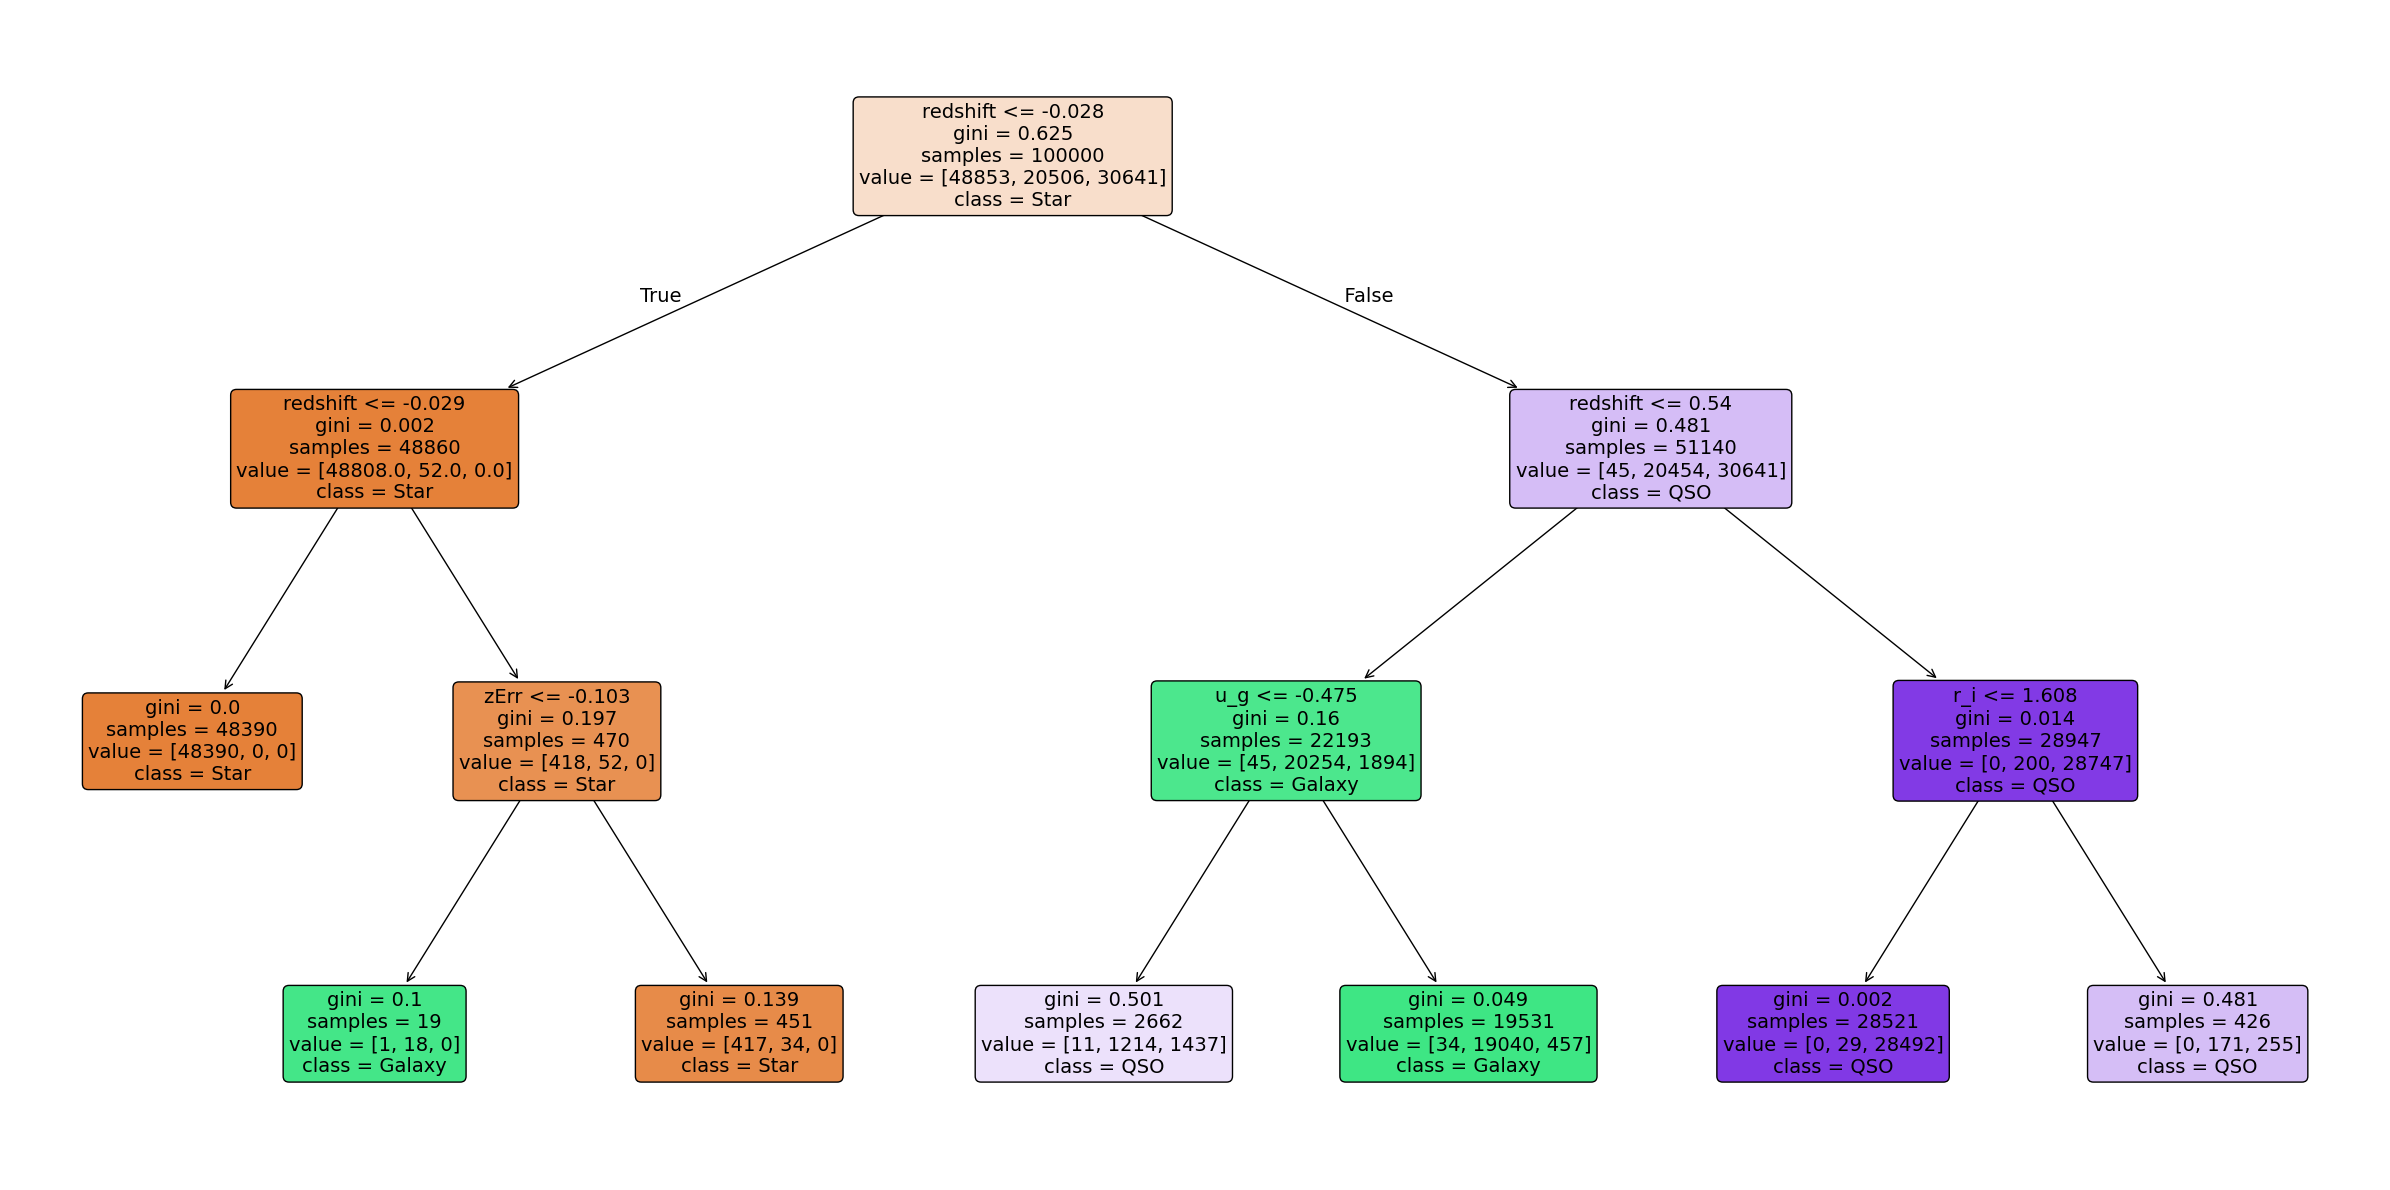

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

ensemble_test_predictions = primary_stacking_ensemble.predict(X_test)

heuristic_surrogate_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
heuristic_surrogate_tree.fit(X_test, ensemble_test_predictions)

plt.figure(figsize=(24, 12))
plot_tree(
    heuristic_surrogate_tree, 
    feature_names=continuous_feature_columns, 
    class_names=['Star', 'Galaxy', 'QSO'],
    filled=True, 
    rounded=True, 
    fontsize=14
)
plt.tight_layout()
plt.show()

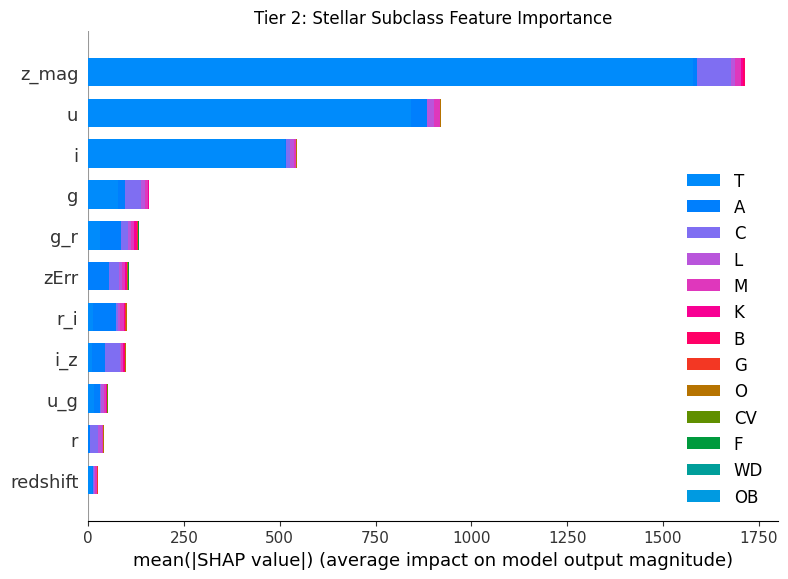

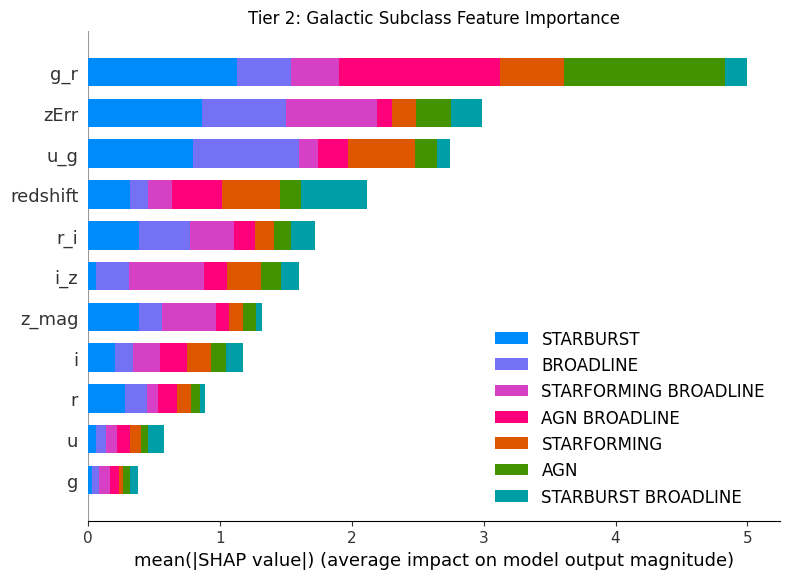

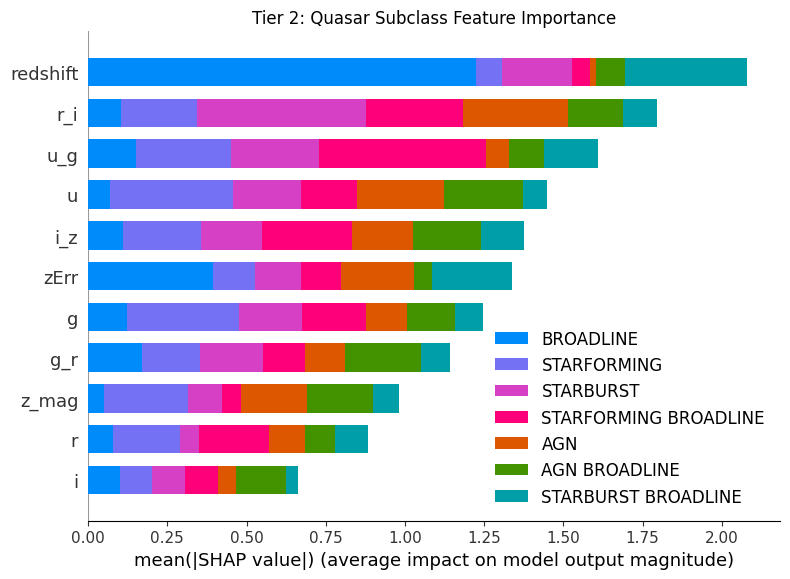

In [20]:
import shap
import matplotlib.pyplot as plt
import numpy as np

shap.initjs()

np.random.seed(42)
sample_size = 10000

idx_stars = np.random.choice(X_stars.shape[0], min(sample_size, X_stars.shape[0]), replace=False)
idx_galaxies = np.random.choice(X_galaxies.shape[0], min(sample_size, X_galaxies.shape[0]), replace=False)
idx_quasars = np.random.choice(X_quasars.shape[0], min(sample_size, X_quasars.shape[0]), replace=False)

X_stars_sample = X_stars[idx_stars]
X_galaxies_sample = X_galaxies[idx_galaxies]
X_quasars_sample = X_quasars[idx_quasars]

lgbm_stars = ensemble_stars.named_estimators_['lgbm']
lgbm_galaxies = ensemble_galaxies.named_estimators_['lgbm']
lgbm_quasars = ensemble_quasars.named_estimators_['lgbm']

explainer_stars = shap.TreeExplainer(lgbm_stars)
explainer_galaxies = shap.TreeExplainer(lgbm_galaxies)
explainer_quasars = shap.TreeExplainer(lgbm_quasars)

shap_stars_raw = explainer_stars.shap_values(X_stars_sample)
shap_galaxies_raw = explainer_galaxies.shap_values(X_galaxies_sample)
shap_quasars_raw = explainer_quasars.shap_values(X_quasars_sample)

num_features = len(continuous_feature_columns)

def enforce_shap_dimensions(shap_raw):
    if isinstance(shap_raw, list):
        return [val[:, :num_features] for val in shap_raw]
    elif isinstance(shap_raw, np.ndarray) and len(shap_raw.shape) == 3:
        if shap_raw.shape[1] == num_features or shap_raw.shape[1] == num_features + 1:
            return [shap_raw[:, :num_features, i] for i in range(shap_raw.shape[2])]
        elif shap_raw.shape[2] == num_features or shap_raw.shape[2] == num_features + 1:
            return [shap_raw[:, i, :num_features] for i in range(shap_raw.shape[1])]
    return shap_raw

shap_values_stars = enforce_shap_dimensions(shap_stars_raw)
shap_values_galaxies = enforce_shap_dimensions(shap_galaxies_raw)
shap_values_quasars = enforce_shap_dimensions(shap_quasars_raw)

plt.figure(figsize=(12, 8))
plt.title("Tier 2: Stellar Subclass Feature Importance")
shap.summary_plot(
    shap_values_stars, 
    X_stars_sample, 
    feature_names=continuous_feature_columns, 
    class_names=list(le_stars.classes_),
    plot_type="bar",
    show=False
)
plt.show()

plt.figure(figsize=(12, 8))
plt.title("Tier 2: Galactic Subclass Feature Importance")
shap.summary_plot(
    shap_values_galaxies, 
    X_galaxies_sample, 
    feature_names=continuous_feature_columns, 
    class_names=list(le_galaxies.classes_),
    plot_type="bar",
    show=False
)
plt.show()

plt.figure(figsize=(12, 8))
plt.title("Tier 2: Quasar Subclass Feature Importance")
shap.summary_plot(
    shap_values_quasars, 
    X_quasars_sample, 
    feature_names=continuous_feature_columns, 
    class_names=list(le_quasars.classes_),
    plot_type="bar",
    show=False
)
plt.show()

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.8s finished


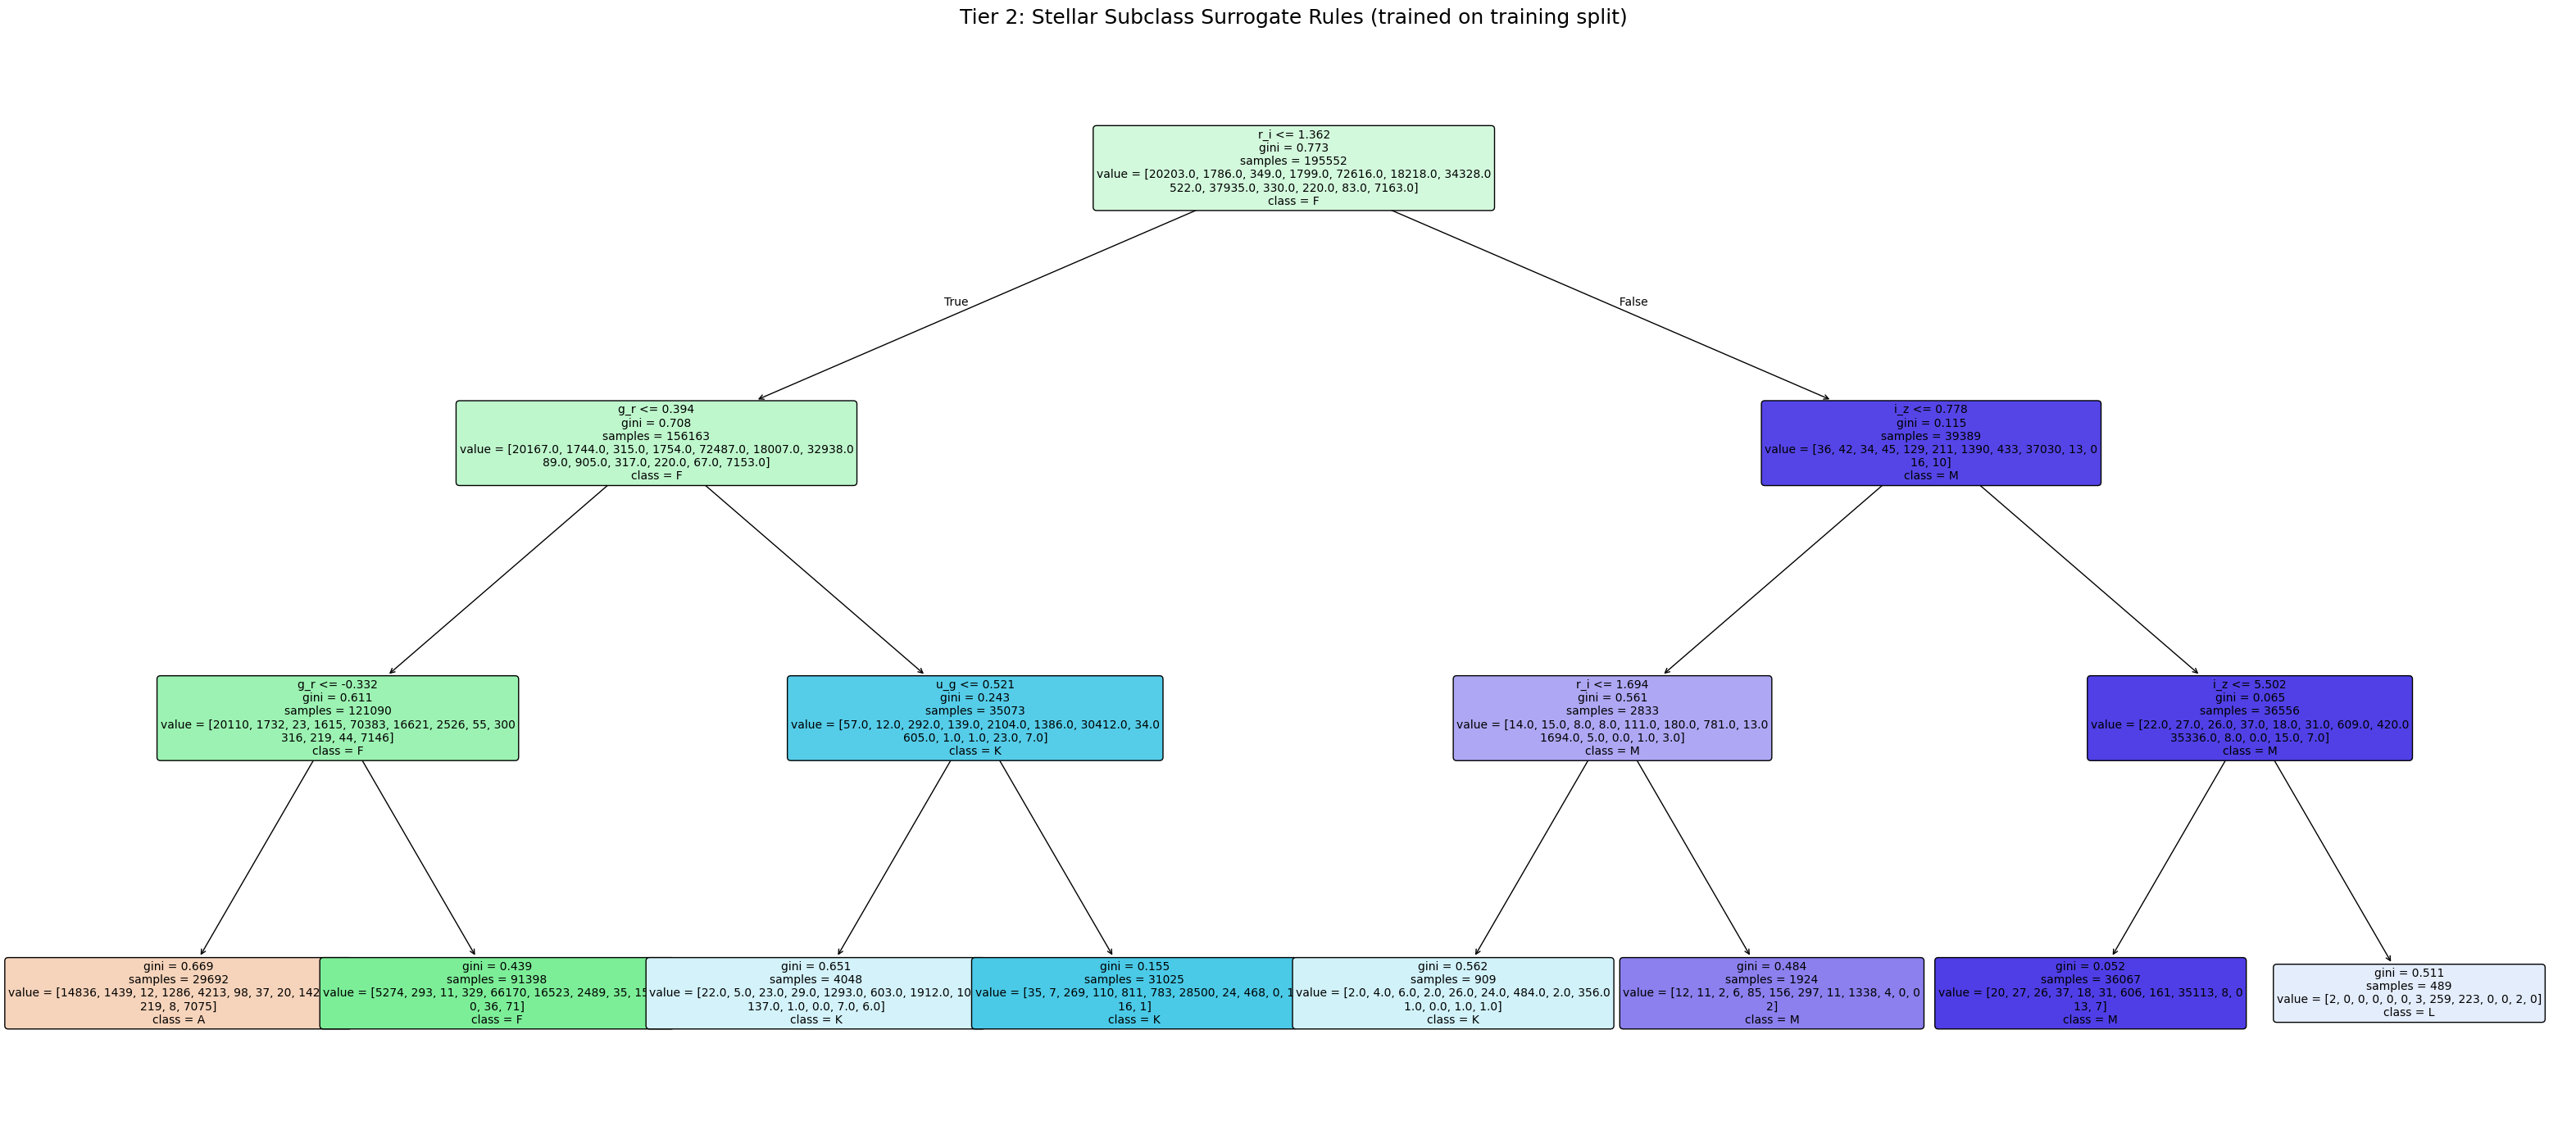

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.6s finished


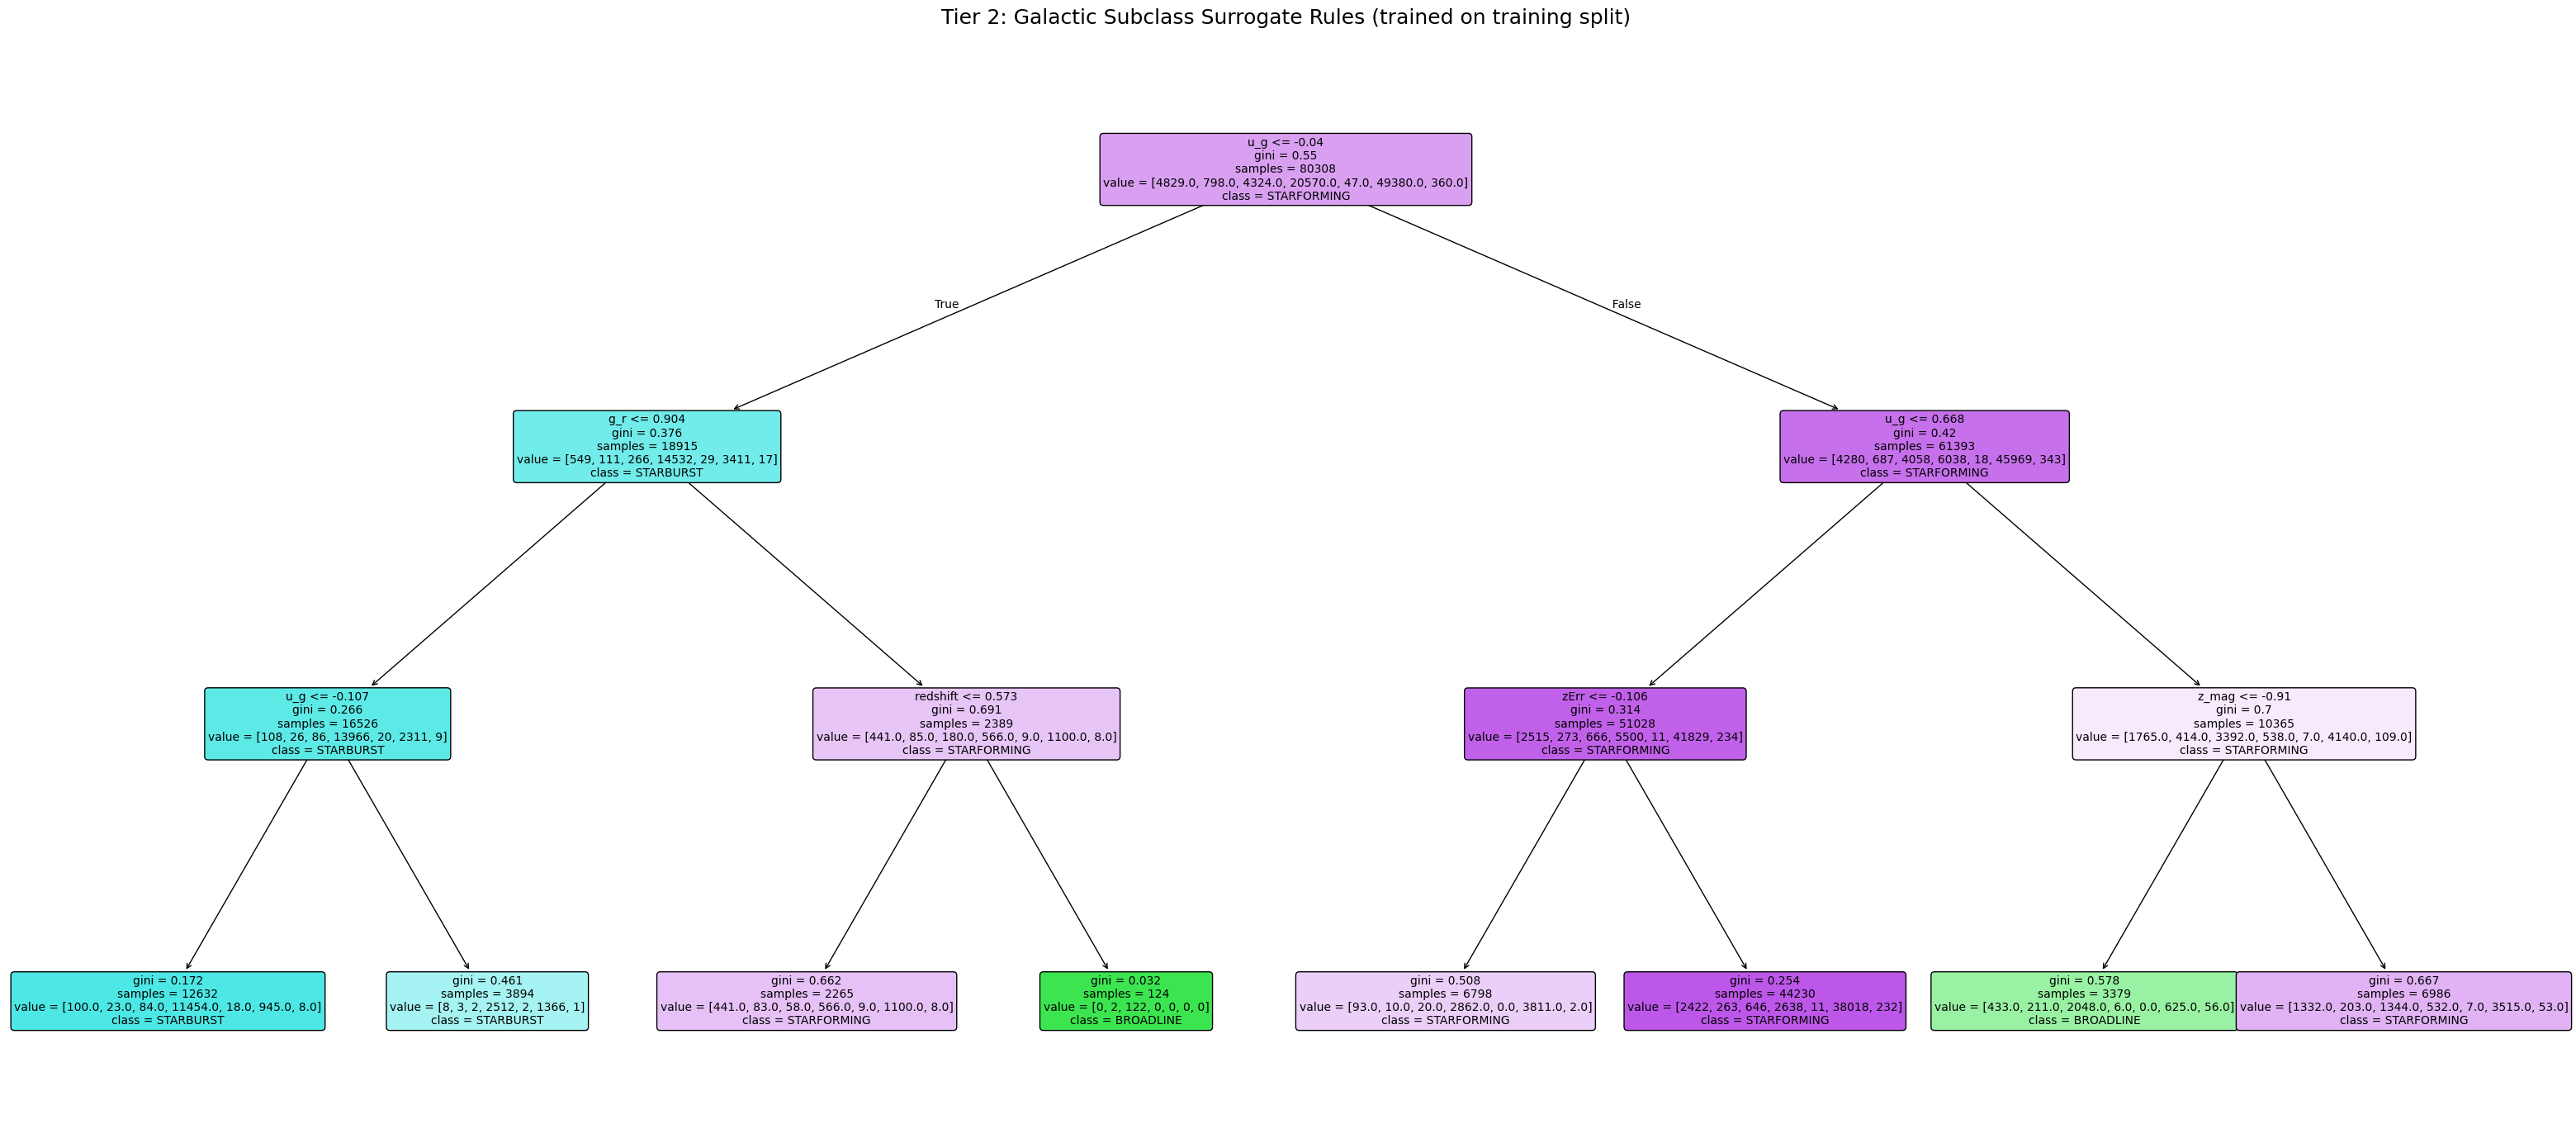

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished


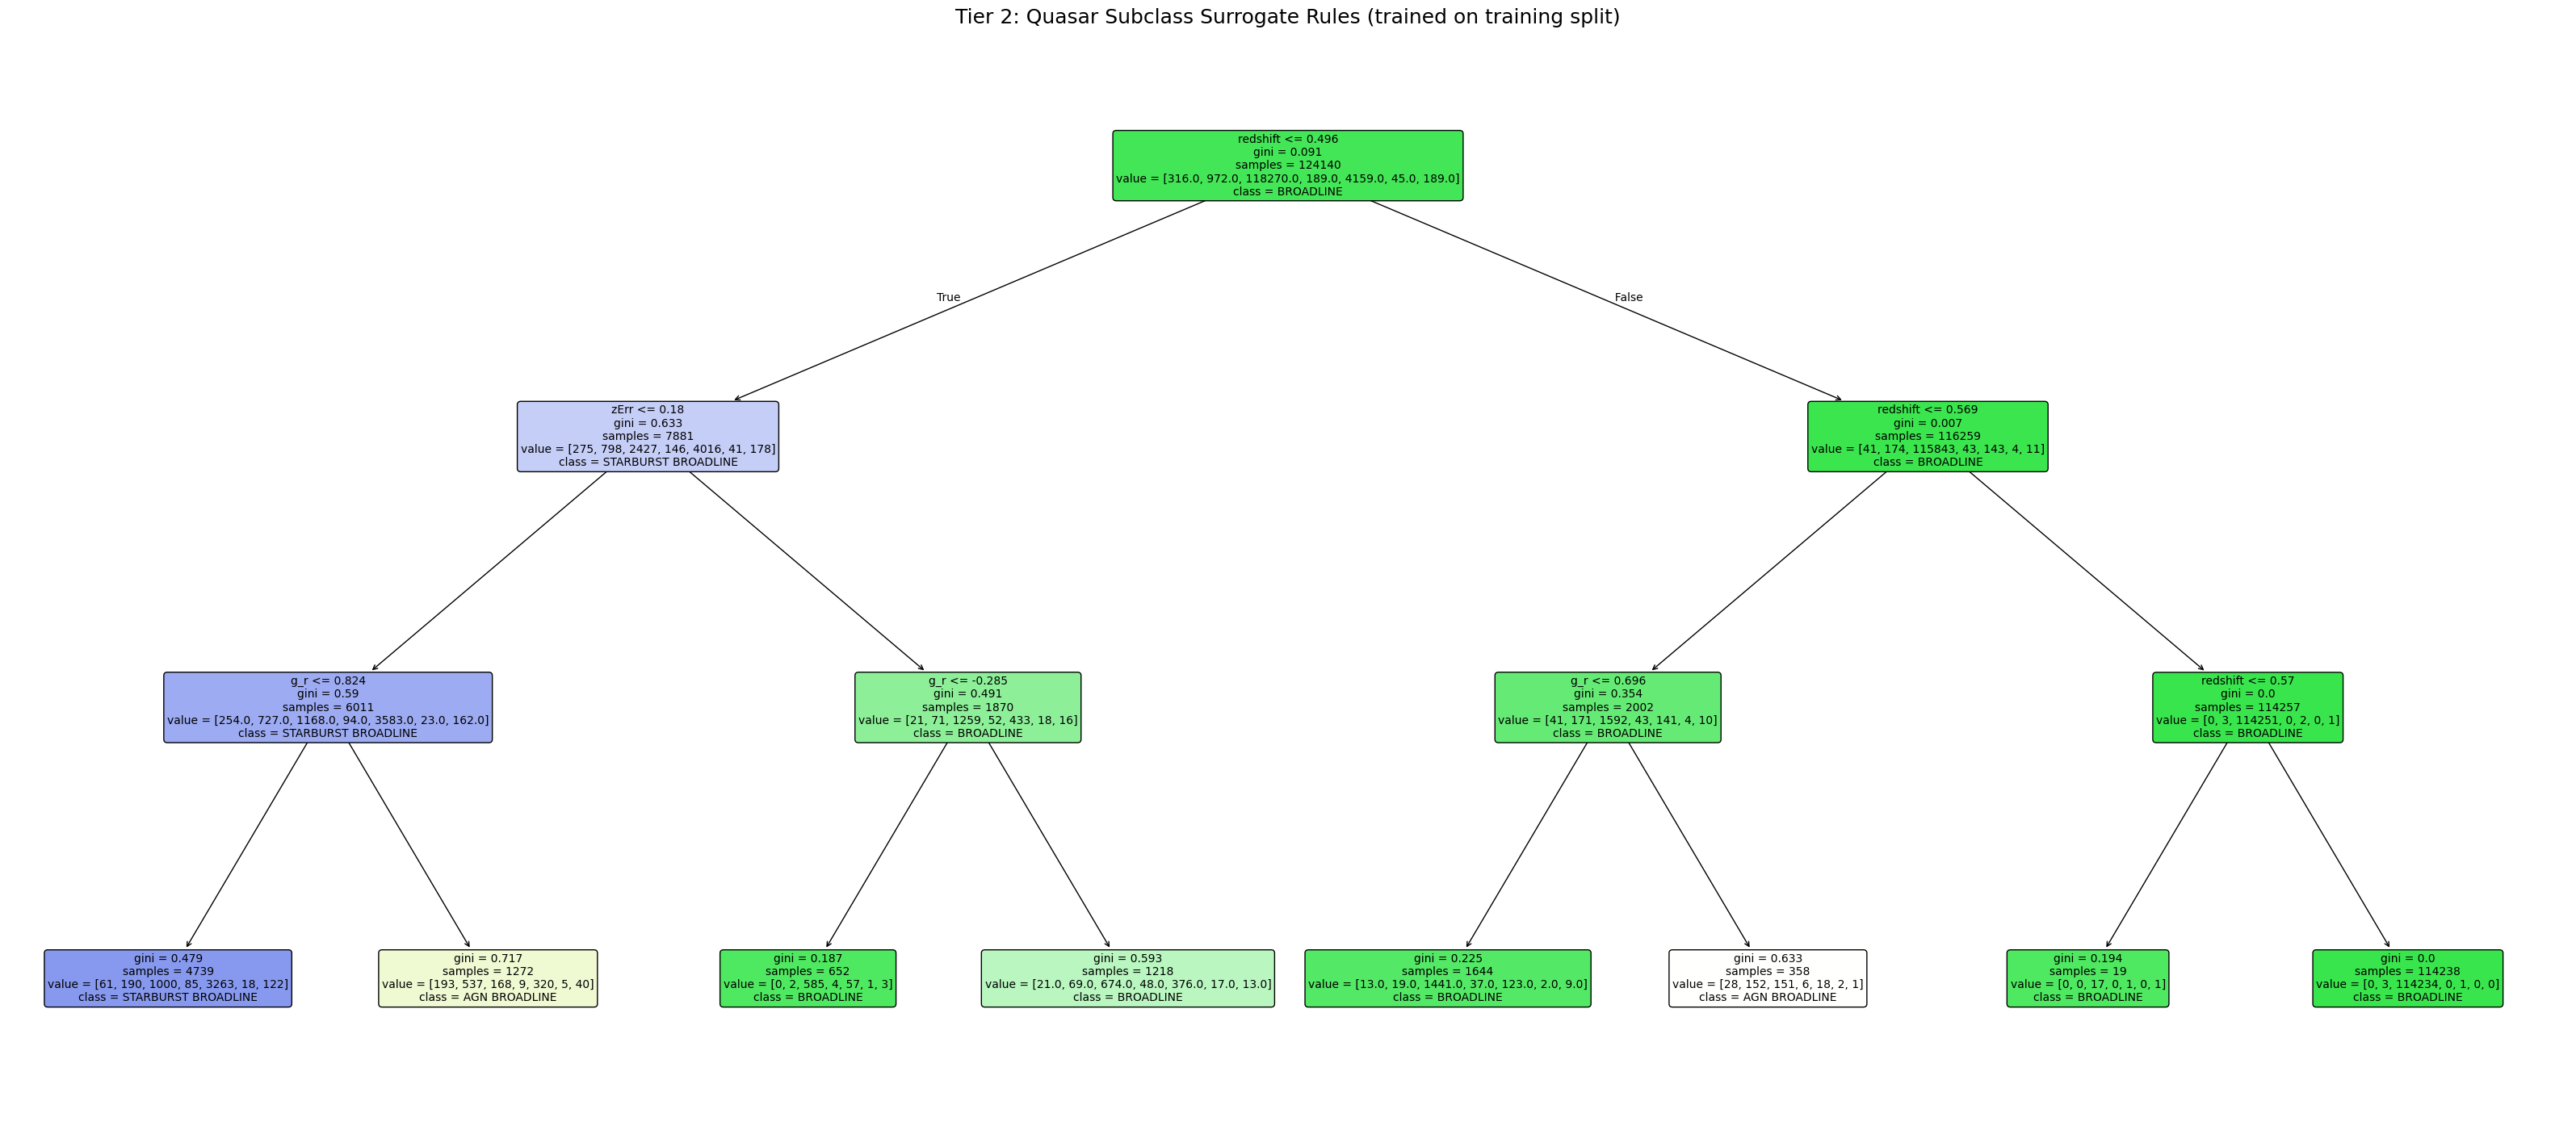

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


pred_stars    = ensemble_stars.predict(X_stars_train)
surrogate_tree_stars = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate_tree_stars.fit(X_stars_train, pred_stars)

plt.figure(figsize=(32, 14))
plot_tree(
    surrogate_tree_stars,
    feature_names=continuous_feature_columns,
    class_names=list(le_stars.classes_),
    filled=True, rounded=True, fontsize=10
)
plt.title("Tier 2: Stellar Subclass Surrogate Rules (trained on training split)", fontsize=18)
plt.tight_layout()
plt.show()

pred_galaxies    = ensemble_galaxies.predict(X_galaxies_train)
surrogate_tree_galaxies = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate_tree_galaxies.fit(X_galaxies_train, pred_galaxies)

plt.figure(figsize=(32, 14))
plot_tree(
    surrogate_tree_galaxies,
    feature_names=continuous_feature_columns,
    class_names=list(le_galaxies.classes_),
    filled=True, rounded=True, fontsize=10
)
plt.title("Tier 2: Galactic Subclass Surrogate Rules (trained on training split)", fontsize=18)
plt.tight_layout()
plt.show()

pred_quasars    = ensemble_quasars.predict(X_quasars_train)
surrogate_tree_quasars = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate_tree_quasars.fit(X_quasars_train, pred_quasars)

plt.figure(figsize=(32, 14))
plot_tree(
    surrogate_tree_quasars,
    feature_names=continuous_feature_columns,
    class_names=list(le_quasars.classes_),
    filled=True, rounded=True, fontsize=10
)
plt.title("Tier 2: Quasar Subclass Surrogate Rules (trained on training split)", fontsize=18)
plt.tight_layout()
plt.show()

--- TIER 1: MACRO-CLASS EVALUATION (TEST SET) ---
              precision    recall  f1-score   support

        STAR     0.9996    0.9989    0.9993     48888
      GALAXY     0.9714    0.9922    0.9817     20077
         QSO     0.9954    0.9828    0.9891     31035

    accuracy                         0.9926    100000
   macro avg     0.9888    0.9913    0.9900    100000
weighted avg     0.9927    0.9926    0.9926    100000



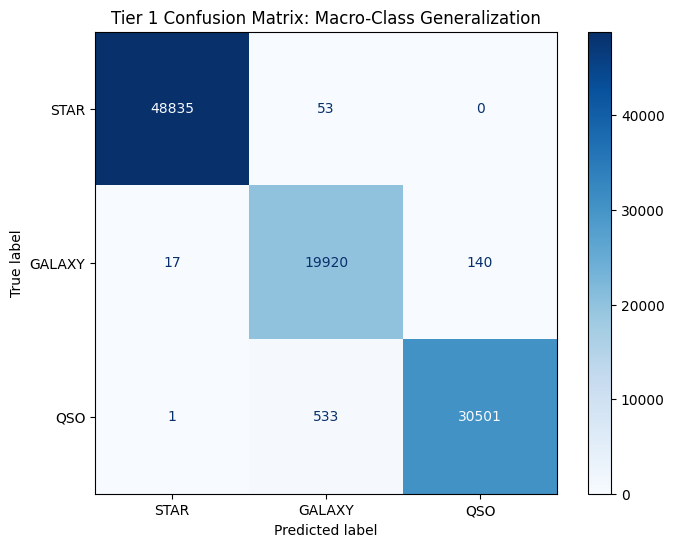

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

y_pred_tier_1 = primary_stacking_ensemble.predict(X_test)

print("--- TIER 1: MACRO-CLASS EVALUATION (TEST SET) ---")
print(classification_report(y_test, y_pred_tier_1, target_names=['STAR', 'GALAXY', 'QSO'], digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
cm_tier_1 = confusion_matrix(y_test, y_pred_tier_1)
disp_tier_1 = ConfusionMatrixDisplay(confusion_matrix=cm_tier_1, display_labels=['STAR', 'GALAXY', 'QSO'])


disp_tier_1.plot(cmap='Blues', ax=ax, values_format='d') 

plt.title("Tier 1 Confusion Matrix: Macro-Class Generalization")
plt.show()

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.5s finished



--- TIER 2: STELLAR SUB-CLASSIFICATION ---
              precision    recall  f1-score   support

           A     0.7859    0.7597    0.7726      5040
           B     0.1479    0.2604    0.1887       384
           C     0.6301    0.6053    0.6174        76
          CV     0.5072    0.7447    0.6034       380
           F     0.8670    0.7990    0.8316     18807
           G     0.4865    0.6302    0.5491      4132
           K     0.9042    0.8874    0.8957      8596
           L     0.3469    0.5930    0.4378        86
           M     0.9642    0.9657    0.9649      9471
           O     0.4500    0.6429    0.5294        70
          OB     0.6182    0.6415    0.6296        53
           T     0.6250    0.5000    0.5556        20
          WD     0.9019    0.9075    0.9047      1773

    accuracy                         0.8266     48888
   macro avg     0.6335    0.6875    0.6523     48888
weighted avg     0.8424    0.8266    0.8328     48888



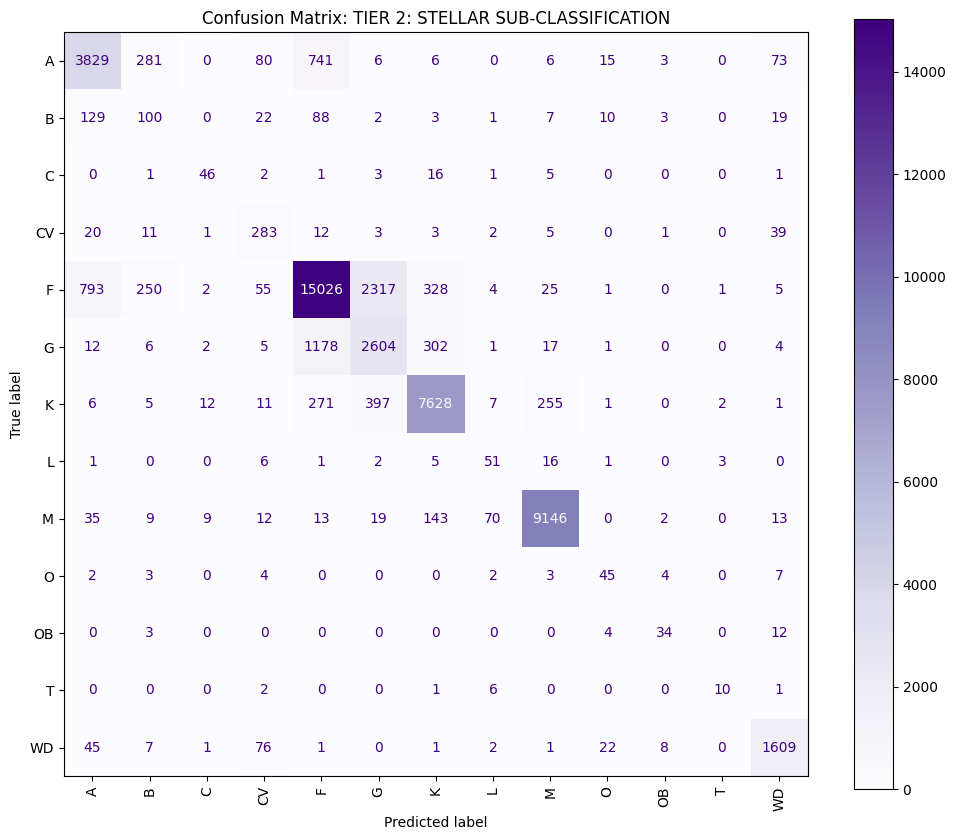

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished



--- TIER 2: GALACTIC SUB-CLASSIFICATION ---
                       precision    recall  f1-score   support

                  AGN     0.3929    0.3082    0.3454      1285
        AGN BROADLINE     0.0938    0.0833    0.0882       180
            BROADLINE     0.5472    0.8082    0.6526       897
            STARBURST     0.7783    0.8485    0.8119      4654
  STARBURST BROADLINE     0.0000    0.0000    0.0000        11
          STARFORMING     0.8886    0.8485    0.8681     12979
STARFORMING BROADLINE     0.0918    0.1268    0.1065        71

             accuracy                         0.8023     20077
            macro avg     0.3989    0.4319    0.4104     20077
         weighted avg     0.8056    0.8023    0.8018     20077



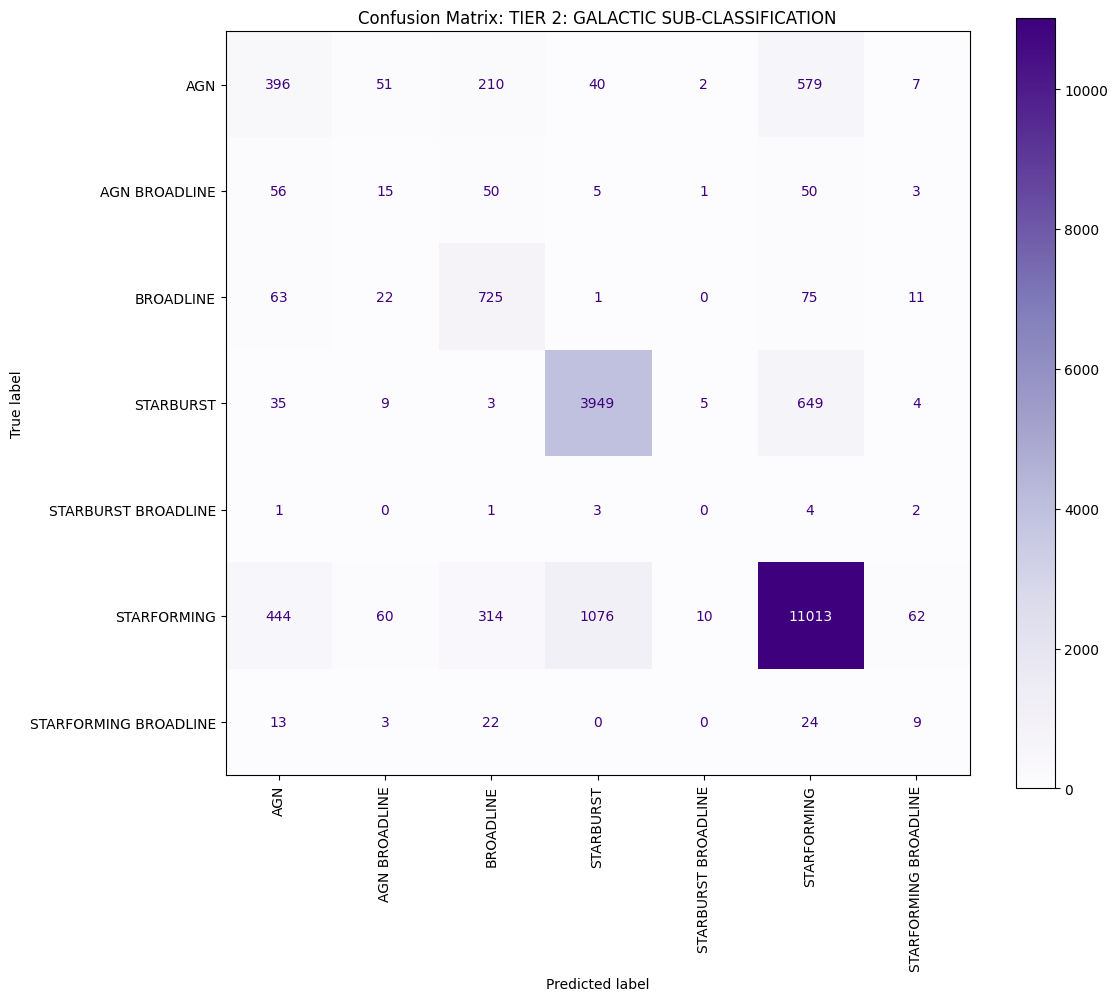

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished



--- TIER 2: QUASAR SUB-CLASSIFICATION ---
                       precision    recall  f1-score   support

                  AGN     0.2281    0.1781    0.2000        73
        AGN BROADLINE     0.4012    0.6341    0.4915       205
            BROADLINE     0.9960    0.9790    0.9874     29899
            STARBURST     0.1212    0.0909    0.1039        44
  STARBURST BROADLINE     0.4975    0.7782    0.6070       762
          STARFORMING     0.0000    0.0000    0.0000        11
STARFORMING BROADLINE     0.1026    0.0976    0.1000        41

             accuracy                         0.9672     31035
            macro avg     0.3352    0.3940    0.3557     31035
         weighted avg     0.9752    0.9672    0.9702     31035



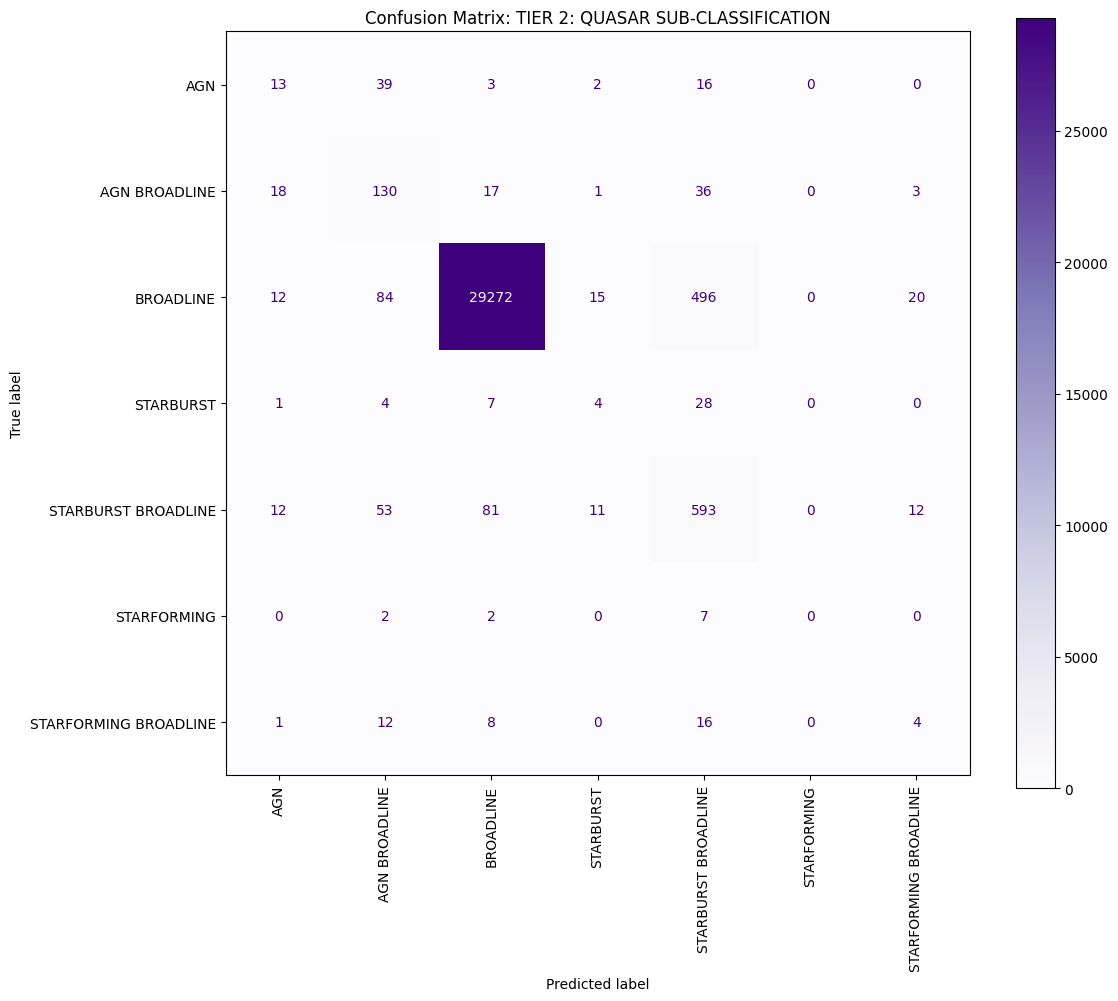

In [23]:
def evaluate_tier_2(ensemble, X, y, label_encoder, title):
    y_pred = ensemble.predict(X)
    print(f"\n--- {title} ---")
    print(classification_report(y, y_pred, target_names=label_encoder.classes_, digits=4))

    fig, ax = plt.subplots(figsize=(12, 10))
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')
    plt.title(f"Confusion Matrix: {title}")
    plt.show()


evaluate_tier_2(ensemble_stars,   X_stars_test,   y_stars_test,   le_stars,   "TIER 2: STELLAR SUB-CLASSIFICATION")
evaluate_tier_2(ensemble_galaxies, X_galaxies_test, y_galaxies_test, le_galaxies, "TIER 2: GALACTIC SUB-CLASSIFICATION")
evaluate_tier_2(ensemble_quasars,  X_quasars_test,  y_quasars_test,  le_quasars,  "TIER 2: QUASAR SUB-CLASSIFICATION")

In [24]:
model_export_package = {
    'tier_1_stacking': primary_stacking_ensemble,
    'tier_2_stars': ensemble_stars,
    'tier_2_galaxies': ensemble_galaxies,
    'tier_2_quasars': ensemble_quasars,
    'scaler': scaler,
    'le_stars': le_stars,
    'le_galaxies': le_galaxies,
    'le_quasars': le_quasars,
    'feature_columns': continuous_feature_columns
}

export_filename = "/kaggle/working/astrophysical_pipeline_v1.pkl"
joblib.dump(model_export_package, export_filename)

print(f"Full hierarchical pipeline successfully exported to: {export_filename}")

Full hierarchical pipeline successfully exported to: /kaggle/working/astrophysical_pipeline_v1.pkl


In [25]:
import os
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import FileLink

os.makedirs('project_plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 6))
cm_tier_1 = confusion_matrix(y_test, y_pred_tier_1)
disp_tier_1 = ConfusionMatrixDisplay(confusion_matrix=cm_tier_1, display_labels=['STAR', 'GALAXY', 'QSO'])
disp_tier_1.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Tier 1 Confusion Matrix")
plt.savefig('project_plots/tier_1_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

def save_tier_2_cm(ensemble, X, y, le, title, filename):
    y_p = ensemble.predict(X)
    fig, ax = plt.subplots(figsize=(12, 10))
    cm = confusion_matrix(y, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Purples', ax=ax, xticks_rotation='vertical', values_format='d')
    plt.title(title)
    plt.savefig(f'project_plots/{filename}.png', dpi=300, bbox_inches='tight')
    plt.close()


save_tier_2_cm(ensemble_stars,    X_stars_test,    y_stars_test,    le_stars,    "Stellar Subclass CM (test set)",  "tier_2_stars_cm")
save_tier_2_cm(ensemble_galaxies, X_galaxies_test, y_galaxies_test, le_galaxies, "Galactic Subclass CM (test set)", "tier_2_galaxies_cm")
save_tier_2_cm(ensemble_quasars,  X_quasars_test,  y_quasars_test,  le_quasars,  "Quasar Subclass CM (test set)",   "tier_2_quasars_cm")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_list, X_test, feature_names=continuous_feature_columns, class_names=['Star', 'Galaxy', 'QSO'], show=False)
plt.savefig('project_plots/tier_1_shap_summary.png', dpi=300, bbox_inches='tight')
plt.close()

def save_surrogate(tree, feat, classes, title, filename):
    plt.figure(figsize=(32, 14))
    plot_tree(tree, feature_names=feat, class_names=list(classes), filled=True, rounded=True, fontsize=10)
    plt.title(title)
    plt.savefig(f'project_plots/{filename}.png', dpi=300, bbox_inches='tight')
    plt.close()

save_surrogate(heuristic_surrogate_tree, continuous_feature_columns, ['Star', 'Galaxy', 'QSO'], "Tier 1 Rules", "tier_1_tree")
save_surrogate(surrogate_tree_stars, continuous_feature_columns, le_stars.classes_, "Stellar Rules", "tier_2_stars_tree")
save_surrogate(surrogate_tree_galaxies, continuous_feature_columns, le_galaxies.classes_, "Galactic Rules", "tier_2_galaxies_tree")
save_surrogate(surrogate_tree_quasars, continuous_feature_columns, le_quasars.classes_, "Quasar Rules", "tier_2_quasars_tree")

shutil.make_archive('astrophysics_final_plots', 'zip', 'project_plots')

display(FileLink('astrophysics_final_plots.zip'))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


/kaggle/working/astrophysics_final_plots.zip